In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv')
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [4]:
df.shape

(37249, 2)

In [5]:
df.sample()['clean_comment'].values

array(['great points one his book series asimov talks about psychohistory think india caught one such event only miracle can stop civil war '],
      dtype=object)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_comment  37149 non-null  object
 1   category       37249 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 582.1+ KB


In [7]:
df.isnull().sum()

,0
clean_comment,100
category,0


In [8]:
df[df['clean_comment'].isna()]

,clean_comment,category
413,NaN,0
605,NaN,0
2422,NaN,0
2877,NaN,0
3307,NaN,0
...,...,...
35975,NaN,0
36036,NaN,0
37043,NaN,0
37111,NaN,0


In [9]:
df[df['clean_comment'].isna()]['category'].value_counts()

,count
category,
0,100


In [10]:
df.dropna(inplace=True)

In [11]:
df.duplicated().sum()
#count duplicats

np.int64(350)

In [12]:
df[df.duplicated()]
#show duplicates

,clean_comment,category
375,,0
392,,0
617,aurum mom,0
651,,0
1222,,0
...,...,...
36915,who won,0
37044,,0
37125,hari,0
37158,top kek,1


In [13]:
df.drop_duplicates(inplace=True)
#remove duplicates

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df[(df['clean_comment'].str.strip()== '')]

,clean_comment,category
181,,0
4432,\n,0
10592,,0
16173,,0
32149,\n,0
34959,,0


In [16]:
df=df[~(df['clean_comment'].str.strip()== '')]

In [17]:
df['clean_comment']=df['clean_comment'].str.lower()
#convert the clean_comment column in lowercase

#verfy the transformation
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [18]:
df[df['clean_comment'].apply(lambda x: x.endswith(' ') or x.startswith(' '))]

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37241,let the janta decide not ulema clerics,0
37242,hona hai same with vaccination education insu...,0
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [19]:
df['clean_comment'] = df['clean_comment'].str.strip()
#remove trailing and leading whitespaces from the clean_comment column

#verfy the transformation
df['clean_comment'].apply(lambda x: x.endswith(' ') or x.startswith(' '))

,clean_comment
0,False
1,False
2,False
3,False
4,False
...,...
37244,False
37245,False
37246,False
37247,False


In [20]:
# identify comments contains url
url_pattern = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
comments_with_urls = df[df['clean_comment'].str.contains(url_pattern, regex=True)]

#display the comments contains urls
comments_with_urls.head()

,clean_comment,category


In [21]:
#identify comments with new line characters
comments_with_newline=df[df['clean_comment'].str.contains('\n')]
comments_with_newline.head()

,clean_comment,category
448,what missing jpg\nand why this brilliant edit ...,1
781,india has been ruined congress and populist sc...,-1
847,like aap for its stand corruption and making p...,-1
871,reduced trade\ndeficit stronger rupee aren the...,0
1354,amsa press conference australian maritime safe...,1


In [22]:
#remove new line charcters
df['clean_comment']=df['clean_comment'].str.replace('\n', ' ', regex=True)

#verify the transformation by checking for any remaining new lines
comments_with_newline_remaining = df[df['clean_comment'].str.contains('\n')]
comments_with_newline_remaining

,clean_comment,category


Export data analysis

<Axes: xlabel='category', ylabel='count'>

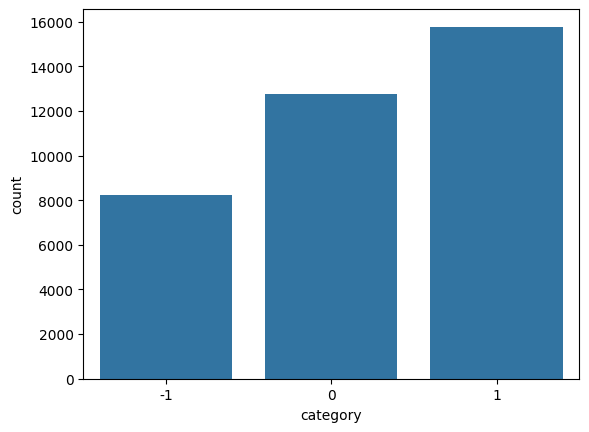

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='category')

In [24]:
#frequency distribution of sentiments
df['category'].value_counts(normalize=True).mul(100).round(2)


,proportion
category,
1,42.86
0,34.71
-1,22.42


In [25]:
df['word_count'] = df['clean_comment'].apply(lambda x: len(x.split()))

In [26]:
df.sample(5)

,clean_comment,category,word_count
10866,took parents all around the foothills the blac...,1,94
33574,holi maja aaega,0,3
27441,piyush goyal concludes his speech lok sabha ad...,0,10
33674,modi much lesser evil than con gress,-1,7
30943,dear bjp cell your efforts would better utilis...,1,17


In [27]:
df['word_count'].describe()

,word_count
count,36793.000000
mean,29.667464
std,56.790738
min,1.000000
25%,6.000000
50%,13.000000
75%,30.000000
max,1307.000000


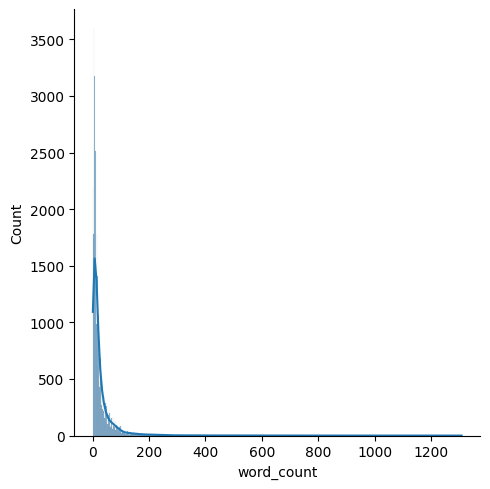

In [28]:
sns.displot(df['word_count'], kde=True)

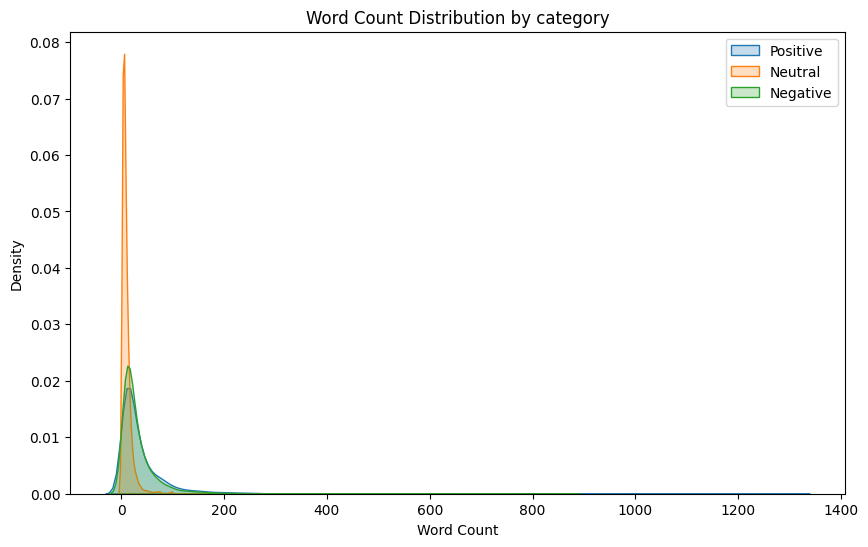

In [29]:
#create the figures and axes
plt.figure(figsize=(10, 6))

#plot KED for category 1
sns.kdeplot(df[df['category'] == 1]['word_count'], label='Positive', fill=True)

#plot KED fot category 0
sns.kdeplot(df[df['category'] == 0]['word_count'], label='Neutral', fill=True)

#plot KED for category -1
sns.kdeplot(df[df['category'] == -1]['word_count'], label='Negative', fill=True)

#add titles, labels and legend
plt.title('Word Count Distribution by category')
plt.xlabel('Word Count')
plt.ylabel('Density')
plt.legend()

#show the plot
plt.show()

<Axes: ylabel='word_count'>

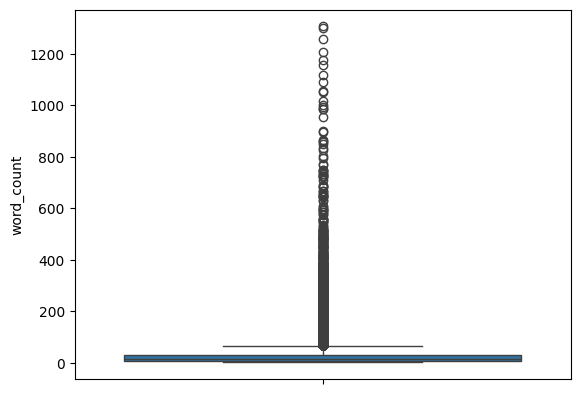

In [30]:
sns.boxplot(df['word_count'])

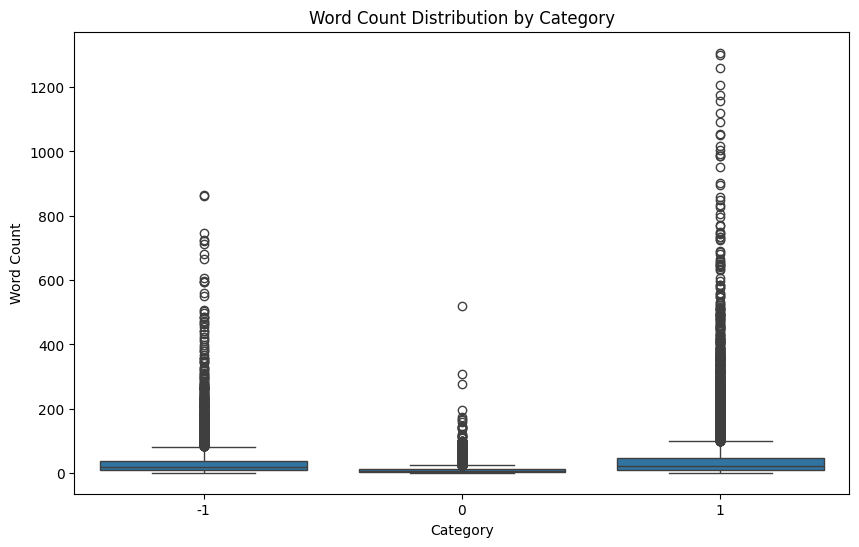

In [31]:
#create a boxplot for the wordcount column catgoryzed by category

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='category', y='word_count')
plt.title('Word Count Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Word Count')
plt.show()

#

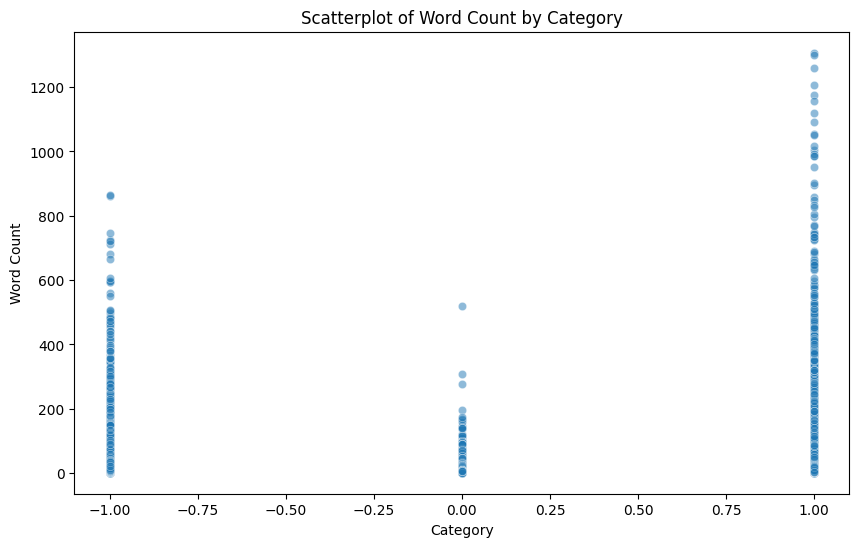

In [32]:
#create a scatter plot between category and wordcount
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='category', y='word_count', alpha=0.5)
plt.title('Scatterplot of Word Count by Category')
plt.xlabel('Category')
plt.ylabel('Word Count')
plt.show()
#

<Axes: xlabel='category', ylabel='word_count'>

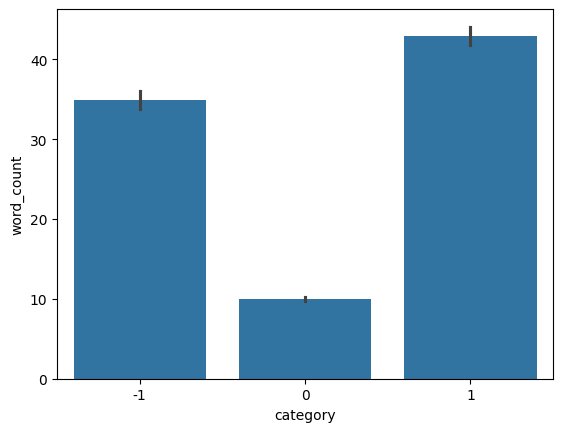

In [33]:
#median word counts among sentiments

sns.barplot(df,x='category', y='word_count')


In [34]:
!pip install nltk

In [35]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

#define the list of english stopwords
stop_words = set(stopwords.words('english'))

#create a new column 'num_stop_words' by counting the number
#of stopwords in each comment
df['num_stop_words'] = df['clean_comment'].apply(lambda x: sum(1 for word in x.split() if word.lower() in stop_words))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [36]:
df.sample(5)

,clean_comment,category,word_count,num_stop_words
10254,don know how far true but there video going vi...,1,176,55
30274,from canada and can afford only month since wi...,1,33,9
8851,bjp not nationalism don mix the two the former...,-1,79,28
20148,are creating history next election slogan,0,6,1
35973,praised for the handling praised whom india le...,0,18,5


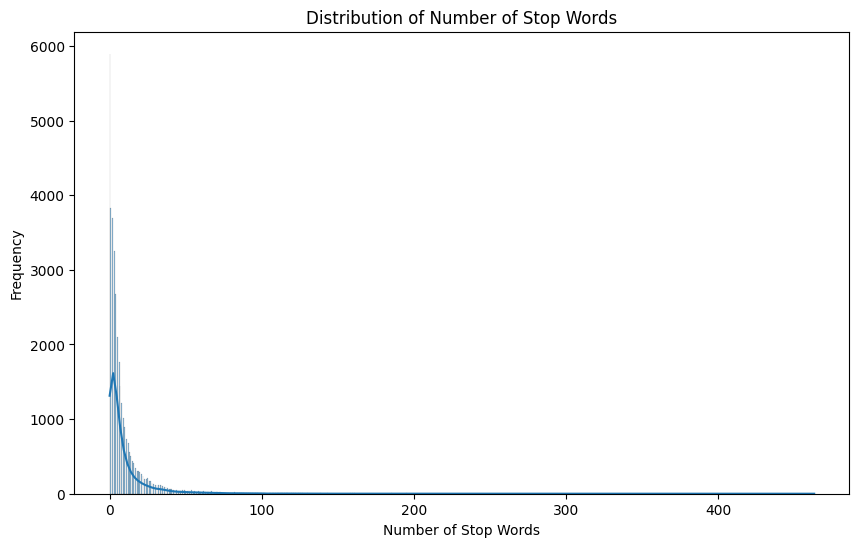

In [37]:
#create a distribution for the num_stop_words
plt.figure(figsize=(10, 6))
sns.histplot(df['num_stop_words'], kde=True)
plt.title('Distribution of Number of Stop Words')
plt.xlabel('Number of Stop Words')
plt.ylabel('Frequency')
plt.show()

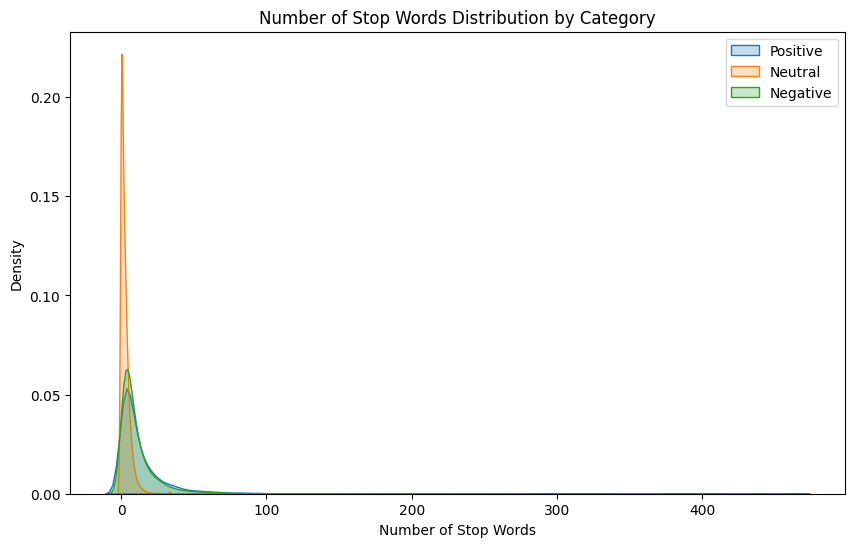

In [38]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['category'] == 1]['num_stop_words'], label='Positive', fill=True)
sns.kdeplot(df[df['category'] == 0]['num_stop_words'], label='Neutral', fill=True)
sns.kdeplot(df[df['category'] == -1]['num_stop_words'], label='Negative', fill=True)

plt.title('Number of Stop Words Distribution by Category')
plt.xlabel('Number of Stop Words')
plt.ylabel('Density')
plt.legend()
plt.show()


<Axes: xlabel='category', ylabel='num_stop_words'>

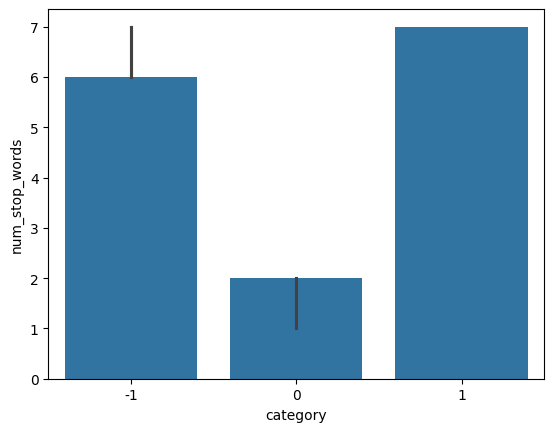

In [39]:
#median words counts among sentiments
sns.barplot(df,x='category', y='num_stop_words', estimator='median')

/tmp/ipykernel_8520/625320929.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_df, x='count', y='stop_word', palette = 'viridis')


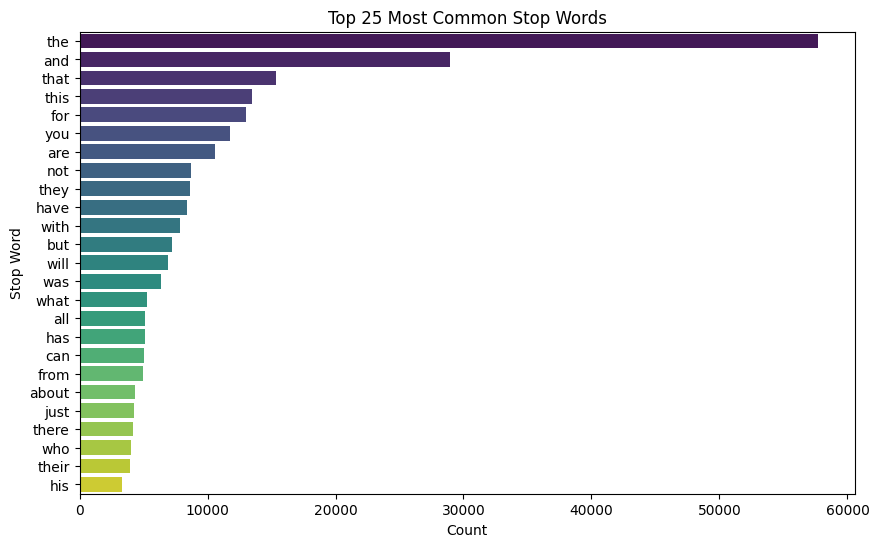

In [40]:
#creae a frequency ditribution of stop words in the clean_comment column
from collections import Counter

#extract all stop words from the comments using the previously defined common_stopwords
all_stop_words = [word for comment in df['clean_comment'] for word in comment.split() if word.lower() in stop_words]

#count the frequency of each stop word
most_common_stop_word_counts = Counter(all_stop_words).most_common(25)

#convert the most common stop words to a data frame for plotting
top_25_df=pd.DataFrame(most_common_stop_word_counts, columns=['stop_word', 'count'])

#create the barplot for the top 25 most common stop words
plt.figure(figsize=(10, 6))
sns.barplot(data=top_25_df, x='count', y='stop_word', palette = 'viridis')
plt.title('Top 25 Most Common Stop Words')
plt.xlabel('Count')
plt.ylabel('Stop Word')
plt.show()

In [41]:
df['num_chars'] = df['clean_comment'].apply(len)

df.head()

,clean_comment,category,word_count,num_stop_words,num_chars
0,family mormon have never tried explain them th...,1,39,13,259
1,buddhism has very much lot compatible with chr...,1,196,59,1268
2,seriously don say thing first all they won get...,-1,86,40,459
3,what you have learned yours and only yours wha...,0,29,15,167
4,for your own benefit you may want read living ...,1,112,45,690


In [42]:
df['num_chars'].describe()

,num_chars
count,36793.000000
mean,181.852798
std,359.702163
min,1.000000
25%,38.000000
50%,80.000000
75%,184.000000
max,8664.000000


In [43]:
from collections import Counter

#combine all components into one large string
all_text=' '.join(df['clean_comment'])

#count the frequency of each character
char_frequency=Counter(all_text)

#convert the character frequency into a data frame for better display
char_frequency_df=pd.DataFrame(char_frequency.items(), columns=['character', 'frequency']).sort_values(by='frequency', ascending=False)

In [44]:
char_frequency_df['character'].values

array([' ', 'e', 't', ..., '呗', 'ഥ', '杨'], dtype=object)

In [45]:
char_frequency_df.tail(50)

,character,frequency
1336,回,1
1337,毫,1
1322,足,1
1323,够,1
1324,假,1
1325,才,1
1326,叫,1
1327,醒,1
1328,妖,1
1329,婆,1


In [46]:
df['num_punctuation_chars'] = df['clean_comment'].apply(
    lambda x: sum([1 for char in x if char in '.,!?;:"\'()[]{}-']))

df.sample(5)

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
9539,inse kuch seekho,0,3,0,16,0
20760,moved ahmedabad years back things that noticed...,1,218,76,1366,0
8707,someone get this man iphone,0,5,1,27,0
17306,this needs dealt politically parents should co...,0,9,2,69,0
27520,thanks rahul baba raised the issue every forum...,1,24,5,140,0


In [47]:
df['num_punctuation_chars'].describe()

,num_punctuation_chars
count,36793.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


/tmp/ipykernel_8520/2123346436.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_bigrams_df, x='count', y='bigram', palette='magma')


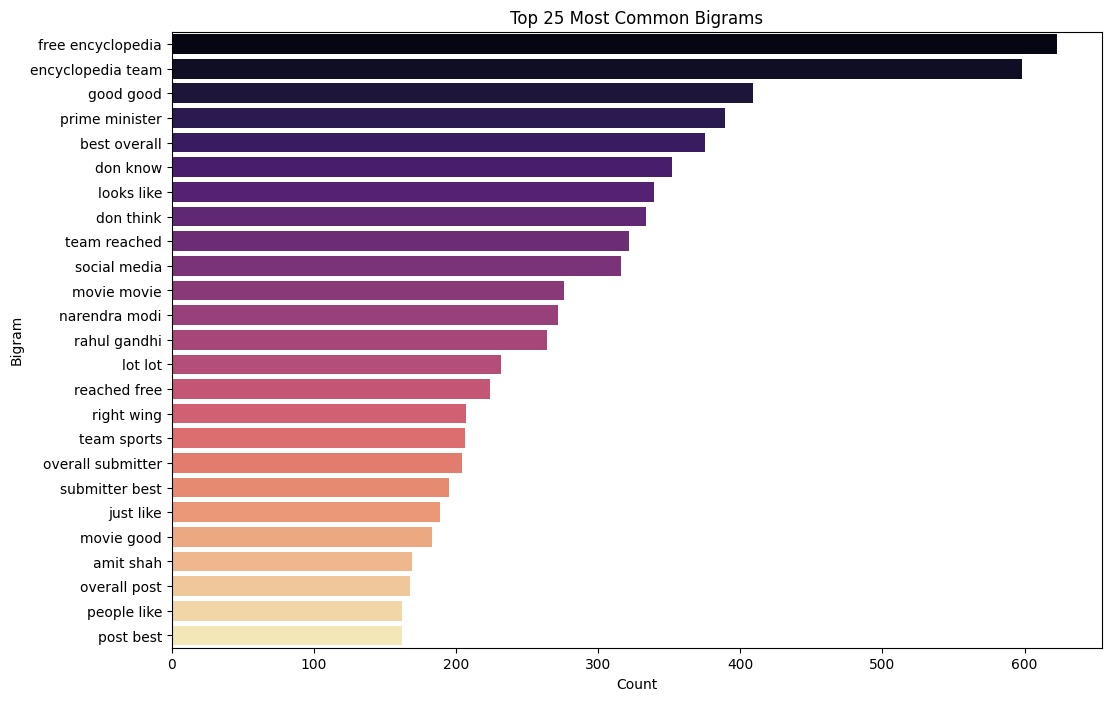

In [48]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#create a function to extract the top 25 bigrams
def get_top_ngrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(2, 2), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words=bag_of_words.sum(axis=0)
    words_freq=[(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq=sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

#get the top 25 bigrams
top_25_bigrams=get_top_ngrams(df['clean_comment'], 25)

top_25_bigrams_df=pd.DataFrame(top_25_bigrams, columns=['bigram', 'count'])

plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_bigrams_df, x='count', y='bigram', palette='magma')
plt.title('Top 25 Most Common Bigrams')
plt.xlabel('Count')
plt.ylabel('Bigram')
plt.show()

/tmp/ipykernel_8520/57830176.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_trigrams_df, x='count', y='trigram', palette='coolwarm')


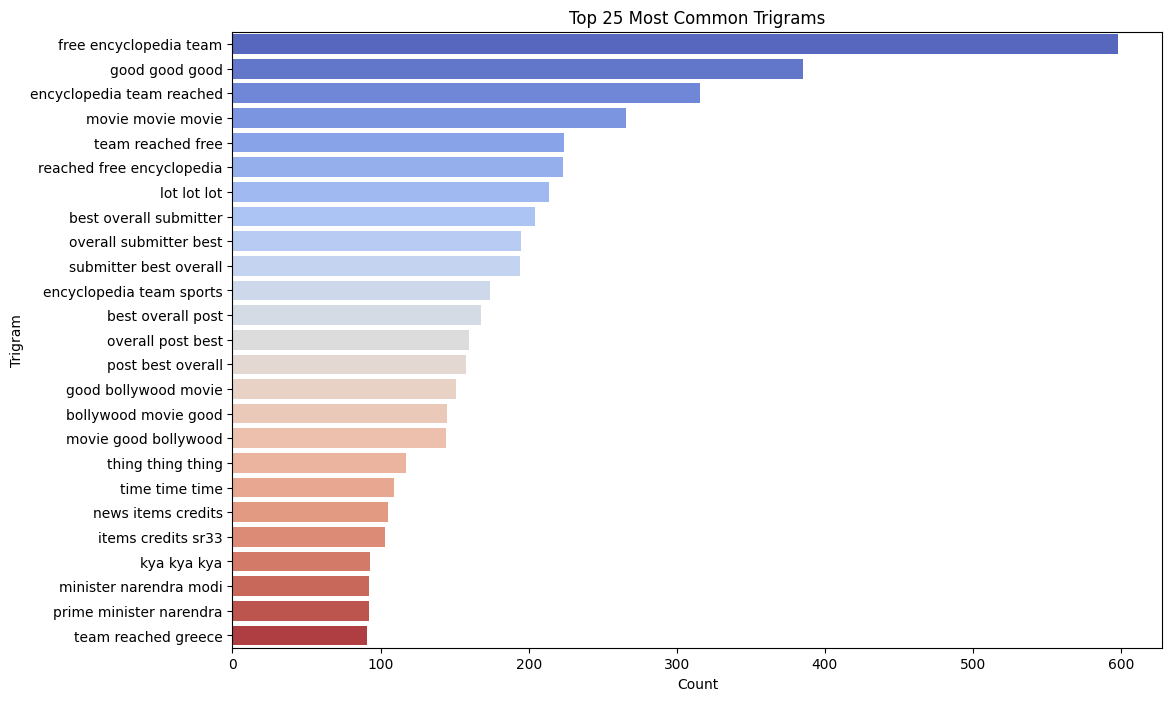

In [49]:
#crate a function to extract the top 25 triagrams
def get_top_trigrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(3, 3), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words=bag_of_words.sum(axis=0)
    words_freq=[(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq=sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# get the top 25 trigrams
top_25_trigrams = get_top_trigrams(df['clean_comment'], 25)

#convert the trigrams into a DataFrame for plotting
top_25_trigrams_df = pd.DataFrame(top_25_trigrams, columns=['trigram', 'count'])

#plot the countplot for the top 25 trigrams
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_trigrams_df, x='count', y='trigram', palette='coolwarm')
plt.title('Top 25 Most Common Trigrams')
plt.xlabel('Count')
plt.ylabel('Trigram')
plt.show()

In [51]:
#remove non-English characters from the 'clean_comment' column
#keeping only standard English letters, digits, and common punctuation
import re

df['clean_comment'] = df['clean_comment'].apply(lambda x: re.sub(r'[^A-Za-z0-9\s!?.,]', '', str(x)))

In [52]:
all_text=' '.join(df['clean_comment'])
char_frequency=Counter(all_text)
char_frequency_df=pd.DataFrame(char_frequency.items(), columns=['character', 'frequency']).sort_values(by='frequency', ascending=False)

char_frequency_df

,character,frequency
6,,1091592
12,e,666610
13,t,491287
1,a,481134
3,i,401388
9,n,388465
7,o,379908
17,s,355279
8,r,331425
10,h,296748


In [53]:
df.head()

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon have never tried explain them th...,1,39,13,259,0
1,buddhism has very much lot compatible with chr...,1,196,59,1268,0
2,seriously don say thing first all they won get...,-1,86,40,459,0
3,what you have learned yours and only yours wha...,0,29,15,167,0
4,for your own benefit you may want read living ...,1,112,45,690,0


In [54]:
from nltk.corpus import stopwords

#defining stop words but keeping esserntial ones for sentiment analysis
stop_words = set(stopwords.words('english')) - {'not','however','but', 'no', 'yet'}
#remove stop words from clean_comment column retaining essential ones
df['clean_comment'] = df['clean_comment'].apply(lambda x: ' '.join([word for word in x.split() if word.lower() not in stop_words]))

In [55]:
df.head()

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,1,39,13,259,0
1,buddhism much lot compatible christianity espe...,1,196,59,1268,0
2,seriously say thing first get complex explain ...,-1,86,40,459,0
3,learned want teach different focus goal not wr...,0,29,15,167,0
4,benefit may want read living buddha living chr...,1,112,45,690,0


In [56]:
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
lemmmatizer = WordNetLemmatizer()
#lemmatizer make a verb in three forms
#apply lemmmatizer to the clean_comment_no_stopwords colomn
df['clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join([lemmmatizer.lemmatize(word) for word in x.split()])
)

df.head()

[nltk_data] Downloading package wordnet to /root/nltk_data...


,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,1,39,13,259,0
1,buddhism much lot compatible christianity espe...,1,196,59,1268,0
2,seriously say thing first get complex explain ...,-1,86,40,459,0
3,learned want teach different focus goal not wr...,0,29,15,167,0
4,benefit may want read living buddha living chr...,1,112,45,690,0


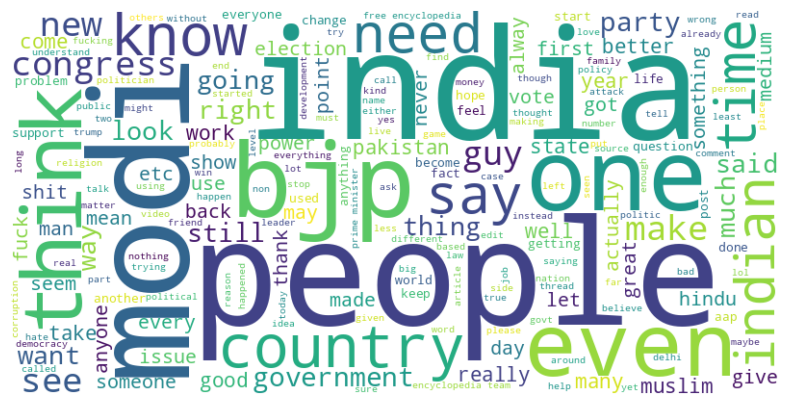

In [58]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
  wordcloud=WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
  plt.figure(figsize=(10,5))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.axis('off')
  plt.show()

plot_word_cloud(df['clean_comment'])

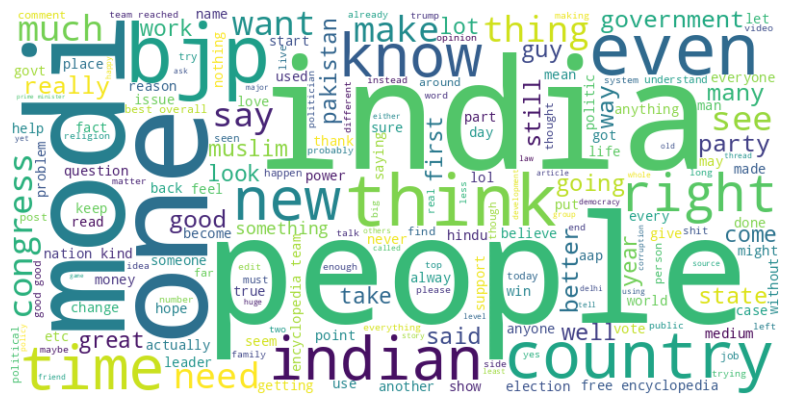

In [59]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
  wordcloud=WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
  plt.figure(figsize=(10,5))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.axis('off')
  plt.show()

plot_word_cloud(df[df['category'] == 1]['clean_comment'])

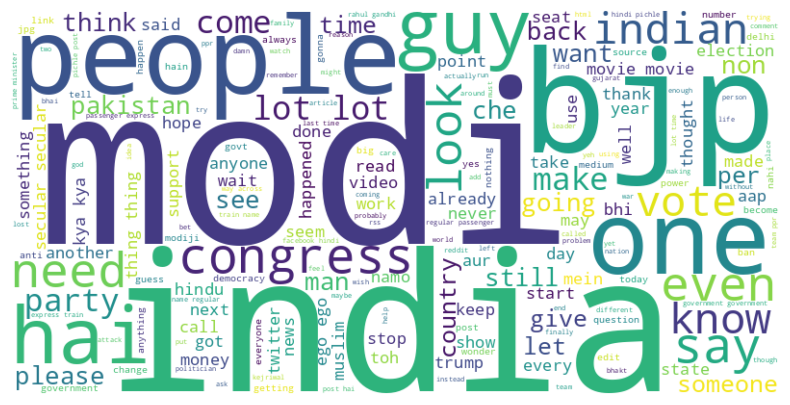

In [60]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

plot_word_cloud(df[df['category'] == 0]['clean_comment'])

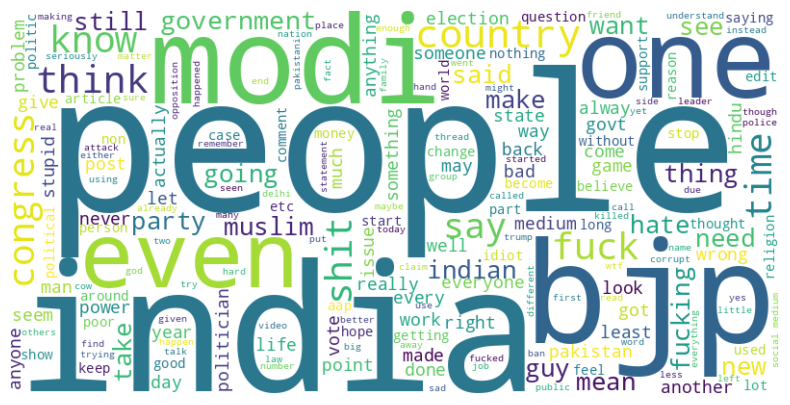

In [61]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

plot_word_cloud(df[df['category'] == -1]['clean_comment'])

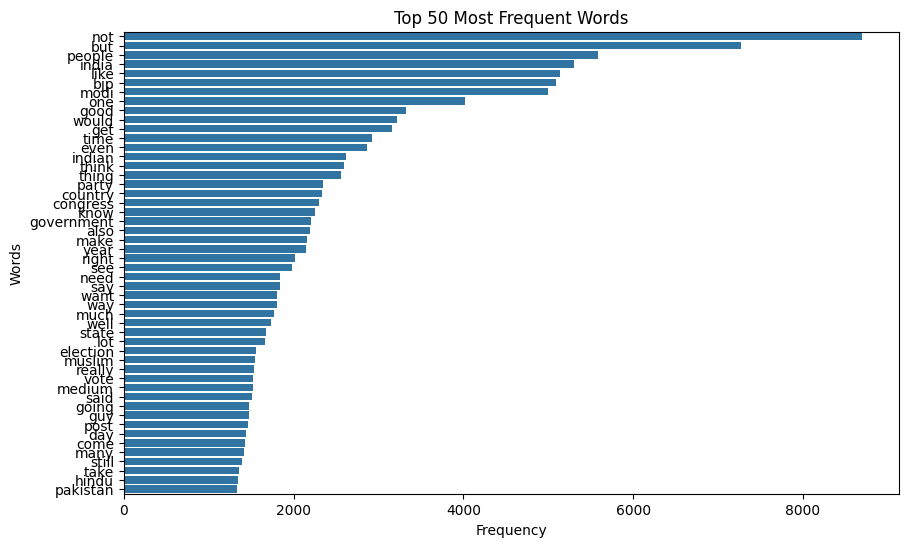

In [62]:
def plot_top_n_words(df, n=20):
    """Plot the top N most frequent words in the dataset."""
    # Flatten all words in the content column
    words = ' '.join(df['clean_comment']).split()

    # Get the top N most common words
    counter = Counter(words)
    most_common_words = counter.most_common(n)

    # Split the words and their counts for plotting
    words, counts = zip(*most_common_words)

    # Plot the top N words
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts), y=list(words))
    plt.title(f'Top {n} Most Frequent Words')
    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.show()

# Example usage
plot_top_n_words(df, n=50)

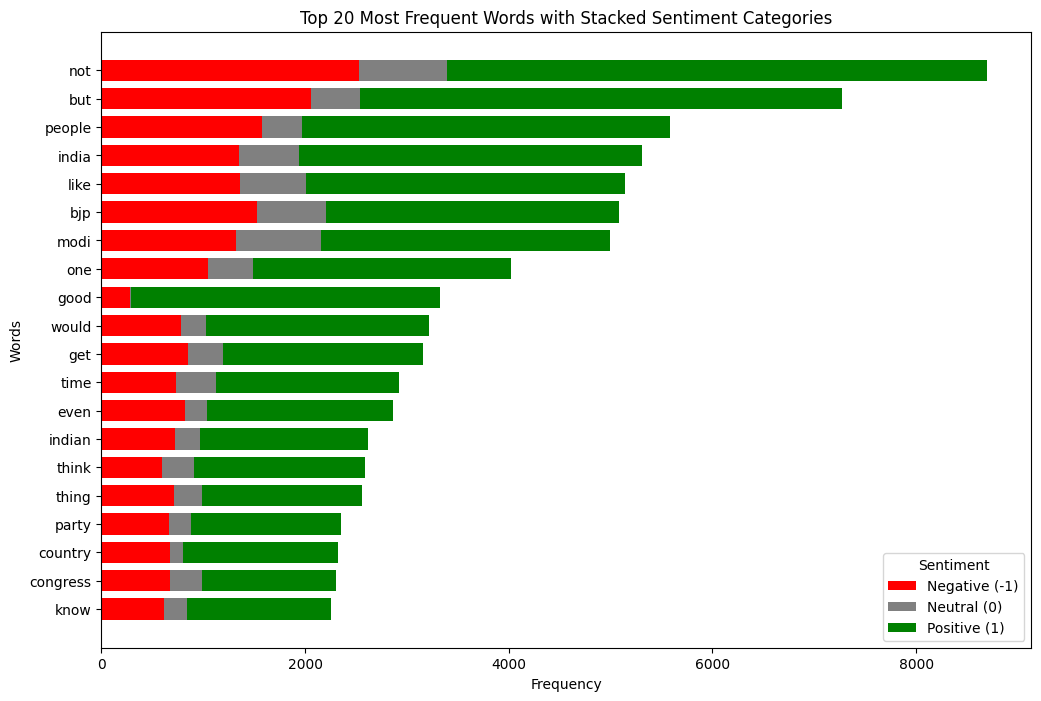

In [63]:
def plot_top_n_words_by_category(df, n=20, start=0):
    """Plot the top N most frequent words in the dataset with stacked hue based on sentiment category."""
    # Flatten all words in the content column and count their occurrences by category
    word_category_counts = {}

    for idx, row in df.iterrows():
        words = row['clean_comment'].split()
        category = row['category']  # Assuming 'category' column exists for -1, 0, 1 labels

        for word in words:
            if word not in word_category_counts:
                word_category_counts[word] = { -1: 0, 0: 0, 1: 0 }  # Initialize counts for each sentiment category

            # Increment the count for the corresponding sentiment category
            word_category_counts[word][category] += 1

    # Get total counts across all categories for each word
    total_word_counts = {word: sum(counts.values()) for word, counts in word_category_counts.items()}

    # Get the top N most frequent words across all categories
    most_common_words = sorted(total_word_counts.items(), key=lambda x: x[1], reverse=True)[start:start+n]
    top_words = [word for word, _ in most_common_words]

    # Prepare data for plotting
    word_labels = top_words
    negative_counts = [word_category_counts[word][-1] for word in top_words]
    neutral_counts = [word_category_counts[word][0] for word in top_words]
    positive_counts = [word_category_counts[word][1] for word in top_words]

    # Plot the stacked bar chart
    plt.figure(figsize=(12, 8))
    bar_width = 0.75

    # Plot negative, neutral, and positive counts in a stacked manner
    plt.barh(word_labels, negative_counts, color='red', label='Negative (-1)', height=bar_width)
    plt.barh(word_labels, neutral_counts, left=negative_counts, color='gray', label='Neutral (0)', height=bar_width)
    plt.barh(word_labels, positive_counts, left=[i+j for i,j in zip(negative_counts, neutral_counts)], color='green', label='Positive (1)', height=bar_width)

    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.title(f'Top {n} Most Frequent Words with Stacked Sentiment Categories')
    plt.legend(title='Sentiment', loc='lower right')
    plt.gca().invert_yaxis()  # Invert y-axis to show the highest frequency at the top
    plt.show()



plot_top_n_words_by_category(df, n=20)
